# Final Outer-Test Evaluation - Frozen Random Forest

All model development and hyperparameter selection were completed before this notebook. Notebook 11 froze the final algorithm and routing strategy. This notebook performs one final evaluation on the previously untouched outer holdout.

**THE OUTER TEST IS USED FOR FINAL EVALUATION ONLY. NO RETUNING OR MODEL-SELECTION DECISION IS PERMITTED AFTER VIEWING THESE RESULTS.**

No result from this notebook may be used to retune, replace, or reroute the frozen model.

## 1. Final-evaluation contract

- Target: `is_canceled`
- Classes: `0 = Not Cancelled`, `1 = Cancelled`
- Approved modelling population: 119,210 rows
- Approved outer split: 95,375 training rows and 23,835 test rows
- Frozen algorithm: Random Forest
- Frozen strategy: General-only
- Primary metric: F1
- Positive class: 1 = Cancelled
- Decision threshold: default 0.5 classifier rule

This is the first notebook permitted to retain `y_test_outer` for final held-out performance evaluation.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, auc, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold

root_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    root for root in root_candidates
    if (root / 'src' / 'preprocessing.py').exists() and (root / 'reports' / 'eval2').exists()
)
if str(PROJECT_ROOT) not in __import__('sys').path:
    __import__('sys').path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    PREDICTOR_FEATURES, TARGET, create_predictor_groups,
    prepare_training_table, split_features_target,
)
from src.modeling import RANDOM_STATE, build_model_pipeline

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'hotel_bookings.csv'
FROZEN_SELECTION_PATH = PROJECT_ROOT / 'reports' / 'eval2' / 'frozen_final_selection.csv'
FINAL_RESULTS_PATH = PROJECT_ROOT / 'reports' / 'eval2' / 'final_outer_test_results.csv'
assert RANDOM_STATE == 42
print(f'Project root: {PROJECT_ROOT}')

Project root: d:\My GitHub Projects\hotel-cancellation


## 2. Load and verify the frozen final selection

These values were determined before outer-test evaluation. A mismatch stops execution instead of silently redesigning the final evaluation.

In [2]:
frozen_selection = pd.read_csv(FROZEN_SELECTION_PATH)
assert len(frozen_selection) == 1
frozen_row = frozen_selection.iloc[0]

def parse_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {'true', '1', 'yes'}

assert frozen_row['selected_algorithm'] == 'Random Forest'
assert frozen_row['final_strategy'] == 'General-only'
assert frozen_row['city_route_scope'] == 'General'
assert frozen_row['resort_route_scope'] == 'General'
assert parse_bool(frozen_row['outer_test_used']) is False

frozen_general_parameters = json.loads(frozen_row['general_parameters'])
assert isinstance(frozen_general_parameters, dict)

frozen_summary = pd.DataFrame({
    'field': [
        'Selected algorithm', 'Selected development stage',
        'General CV F1', 'General CV Recall', 'General CV ROC-AUC',
        'Final strategy', 'City route', 'Resort route', 'Frozen parameters',
    ],
    'value': [
        frozen_row['selected_algorithm'], frozen_row['general_selected_stage'],
        frozen_row['general_selected_cv_f1'], frozen_row['general_selected_cv_recall'],
        frozen_row['general_selected_cv_roc_auc'], frozen_row['final_strategy'],
        frozen_row['city_route_scope'], frozen_row['resort_route_scope'],
        json.dumps(frozen_general_parameters, sort_keys=True),
    ],
})
display(frozen_summary)

,field,value
0,Selected algorithm,Random Forest
1,Selected development stage,tuned
2,General CV F1,0.821846
3,General CV Recall,0.841707
4,General CV ROC-AUC,0.943806
5,Final strategy,General-only
6,City route,General
7,Resort route,General
8,Frozen parameters,"{""bootstrap"": true, ""class_weight"": ""balanced""..."


## 3. Reconstruct the exact approved outer holdout

The first split of the approved five-fold `StratifiedGroupKFold` is recreated exactly. No alternate seed, fold, or split is searched.

In [3]:
raw_df = pd.read_csv(RAW_PATH)
training_table = prepare_training_table(raw_df)
X, y = split_features_target(training_table)
predictor_groups = create_predictor_groups(X)

outer_splitter = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
train_positions, test_positions = next(
    outer_splitter.split(X, y, groups=predictor_groups)
)

X_train_outer = X.iloc[train_positions].copy()
X_test_outer = X.iloc[test_positions].copy()
y_train_outer = y.iloc[train_positions].copy()
y_test_outer = y.iloc[test_positions].copy()
groups_train_outer = predictor_groups.iloc[train_positions].copy()
groups_test_outer = predictor_groups.iloc[test_positions].copy()

assert len(training_table) == 119_210
assert len(X_train_outer) == 95_375
assert len(X_test_outer) == 23_835
assert set(groups_train_outer).isdisjoint(set(groups_test_outer))

def profile_index(frame):
    return pd.MultiIndex.from_frame(frame.loc[:, list(PREDICTOR_FEATURES)])

profile_overlap = profile_index(X_train_outer).intersection(profile_index(X_test_outer))
assert len(profile_overlap) == 0

print('Outer holdout verified:', len(X_train_outer), 'train rows;', len(X_test_outer), 'test rows')

Outer holdout verified: 95375 train rows; 23835 test rows


## 4. Final test population structure

These are structural counts only. Target performance is not used for any decision here.

In [4]:
city_test_mask = X_test_outer['hotel'].eq('City Hotel')
resort_test_mask = X_test_outer['hotel'].eq('Resort Hotel')
test_population_summary = pd.DataFrame({
    'evaluation_population': ['Overall', 'City', 'Resort'],
    'rows': [len(X_test_outer), int(city_test_mask.sum()), int(resort_test_mask.sum())],
})
assert int(city_test_mask.sum()) == 16_119
assert int(resort_test_mask.sum()) == 7_716
assert int(city_test_mask.sum()) + int(resort_test_mask.sum()) == len(X_test_outer)
display(test_population_summary)

,evaluation_population,rows
0,Overall,23835
1,City,16119
2,Resort,7716


## 5. Build and fit the one frozen General Random Forest

Exactly one General Random Forest is constructed from the frozen parameter dictionary and fitted once on all 95,375 outer-training rows. No specialist model is fitted because the frozen strategy is General-only.

In [5]:
final_estimator = RandomForestClassifier(**frozen_general_parameters)
final_pipeline = build_model_pipeline(X_train_outer, final_estimator)

fit_started = time.perf_counter()
final_pipeline.fit(X_train_outer, y_train_outer)
fit_seconds = time.perf_counter() - fit_started
print(f'Final General Random Forest fit completed in {fit_seconds:.2f} seconds.')

Final General Random Forest fit completed in 1249.86 seconds.


## 6. Predict the outer test once

The default classifier threshold is retained. No alternative threshold is evaluated or optimized.

In [6]:
test_predictions = final_pipeline.predict(X_test_outer)
test_probabilities = final_pipeline.predict_proba(X_test_outer)[:, 1]
assert len(test_predictions) == 23_835
assert len(test_probabilities) == 23_835
assert np.isfinite(test_probabilities).all()
assert not pd.isna(test_predictions).any()
assert set(np.unique(test_predictions)).issubset({0, 1})
assert np.logical_and(test_probabilities >= 0, test_probabilities <= 1).all()

## 7. Final metric helper and results

ROC-AUC uses continuous cancellation probabilities. Accuracy, Precision, Recall, and F1 use the default hard predictions with class `1` as the positive class.

In [7]:
def final_metric_record(y_true, predictions, probabilities):
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'rows': len(y_true),
        'accuracy': accuracy_score(y_true, predictions),
        'precision': precision_score(y_true, predictions, pos_label=1, zero_division=0),
        'recall': recall_score(y_true, predictions, pos_label=1, zero_division=0),
        'f1': f1_score(y_true, predictions, pos_label=1, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }

population_masks = {
    'Overall': pd.Series(True, index=X_test_outer.index),
    'City': city_test_mask,
    'Resort': resort_test_mask,
}
final_records = []
parameter_text = json.dumps(frozen_general_parameters, sort_keys=True)
for population, mask in population_masks.items():
    metrics = final_metric_record(
        y_test_outer.loc[mask], test_predictions[mask.to_numpy()], test_probabilities[mask.to_numpy()]
    )
    final_records.append({
        'algorithm': 'Random Forest',
        'model_scope': 'General',
        'evaluation_population': population,
        **metrics,
        'threshold': 0.5,
        'strategy': 'General-only',
        'parameters': parameter_text,
    })

final_outer_test_results = pd.DataFrame(final_records)
assert len(final_outer_test_results) == 3
assert final_outer_test_results['evaluation_population'].tolist() == ['Overall', 'City', 'Resort']
assert final_outer_test_results['algorithm'].eq('Random Forest').all()
assert final_outer_test_results['model_scope'].eq('General').all()
assert final_outer_test_results['strategy'].eq('General-only').all()
display(final_outer_test_results)

# This writes the final result only when a student executes the notebook later.
final_outer_test_results.to_csv(FINAL_RESULTS_PATH, index=False)

,algorithm,model_scope,evaluation_population,rows,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,threshold,strategy,parameters
0,Random Forest,General,Overall,23835,0.864401,0.796822,0.851290,0.823156,0.941849,13081,1918,1314,7522,0.5,General-only,"{""bootstrap"": true, ""class_weight"": ""balanced""..."
1,Random Forest,General,City,16119,0.856070,0.811934,0.857101,0.833906,0.937128,7975,1349,971,5824,0.5,General-only,"{""bootstrap"": true, ""class_weight"": ""balanced""..."
2,Random Forest,General,Resort,7716,0.881804,0.749007,0.831945,0.788301,0.946813,5106,569,343,1698,0.5,General-only,"{""bootstrap"": true, ""class_weight"": ""balanced""..."


## 8. Confusion matrices and descriptive ROC curve

The ROC curve is descriptive only; it is not used for threshold optimization.

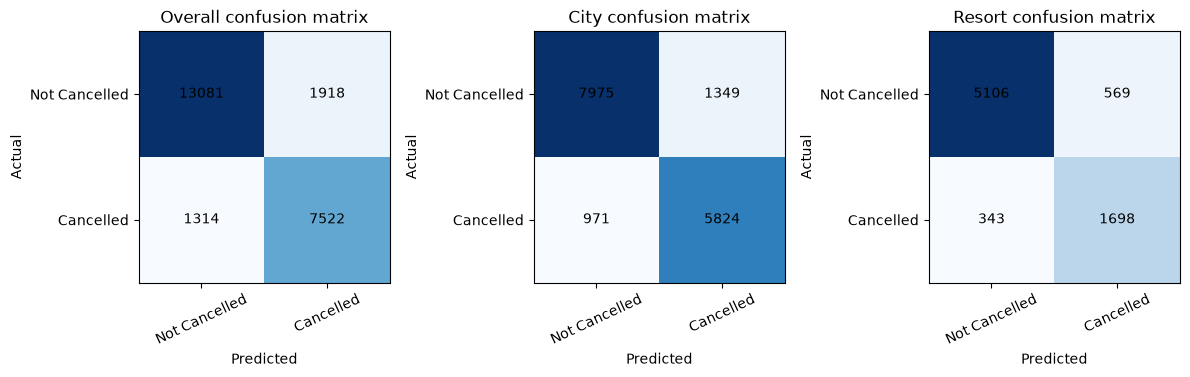

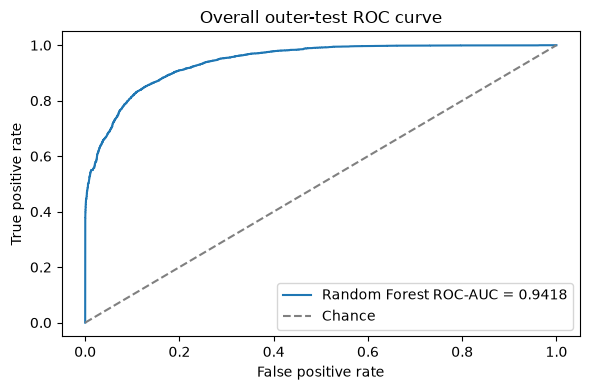

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for axis, population in zip(axes, ['Overall', 'City', 'Resort']):
    mask = population_masks[population]
    matrix = confusion_matrix(y_test_outer.loc[mask], test_predictions[mask.to_numpy()], labels=[0, 1])
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(f'{population} confusion matrix')
    axis.set_xlabel('Predicted')
    axis.set_ylabel('Actual')
    axis.set_xticks([0, 1], ['Not Cancelled', 'Cancelled'], rotation=25)
    axis.set_yticks([0, 1], ['Not Cancelled', 'Cancelled'])
    for row in range(2):
        for column in range(2):
            axis.text(column, row, matrix[row, column], ha='center', va='center')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test_outer, test_probabilities, pos_label=1)
overall_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Random Forest ROC-AUC = {overall_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Overall outer-test ROC curve')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Development versus final outer-test context

This comparison is interpretation only. No development-to-test difference may be used to retune, change the algorithm, change parameters, change the threshold, or change the routing strategy.

In [9]:
development_vs_test = pd.DataFrame({
    'metric': ['F1', 'Recall', 'ROC-AUC'],
    'development grouped-CV': [
        frozen_row['general_selected_cv_f1'],
        frozen_row['general_selected_cv_recall'],
        frozen_row['general_selected_cv_roc_auc'],
    ],
    'final outer test': [
        final_outer_test_results.loc[final_outer_test_results['evaluation_population'].eq('Overall'), 'f1'].iloc[0],
        final_outer_test_results.loc[final_outer_test_results['evaluation_population'].eq('Overall'), 'recall'].iloc[0],
        final_outer_test_results.loc[final_outer_test_results['evaluation_population'].eq('Overall'), 'roc_auc'].iloc[0],
    ],
})
development_vs_test['difference'] = development_vs_test['final outer test'] - development_vs_test['development grouped-CV']
display(development_vs_test)
display(Markdown('A development-to-test difference is a descriptive generalization gap, not proof of absence or presence of overfitting.'))

,metric,development grouped-CV,final outer test,difference
0,F1,0.821846,0.823156,0.001310
1,Recall,0.841707,0.851290,0.009583
2,ROC-AUC,0.943806,0.941849,-0.001956


A development-to-test difference is a descriptive generalization gap, not proof of absence or presence of overfitting.

## Final Outer-Test Findings

This is the final held-out evaluation of the frozen modelling decision. No claim of perfection, guarantee, or universal superiority is made.

In [10]:
overall_result = final_outer_test_results.loc[
    final_outer_test_results['evaluation_population'].eq('Overall')
].iloc[0]
city_result = final_outer_test_results.loc[
    final_outer_test_results['evaluation_population'].eq('City')
].iloc[0]
resort_result = final_outer_test_results.loc[
    final_outer_test_results['evaluation_population'].eq('Resort')
].iloc[0]

findings = [
    f"- Frozen algorithm: Random Forest; frozen strategy: General-only.",
    f"- Overall outer-test rows: {int(overall_result['rows'])}.",
    f"- Overall Accuracy={overall_result['accuracy']:.4f}; Precision={overall_result['precision']:.4f}; "
      f"Recall={overall_result['recall']:.4f}; F1={overall_result['f1']:.4f}; ROC-AUC={overall_result['roc_auc']:.4f}.",
    f"- Overall confusion matrix: TN={int(overall_result['tn'])}, FP={int(overall_result['fp'])}, "
      f"FN={int(overall_result['fn'])}, TP={int(overall_result['tp'])}.",
    f"- City subgroup: Accuracy={city_result['accuracy']:.4f}; Precision={city_result['precision']:.4f}; "
      f"Recall={city_result['recall']:.4f}; F1={city_result['f1']:.4f}; ROC-AUC={city_result['roc_auc']:.4f}.",
    f"- Resort subgroup: Accuracy={resort_result['accuracy']:.4f}; Precision={resort_result['precision']:.4f}; "
      f"Recall={resort_result['recall']:.4f}; F1={resort_result['f1']:.4f}; ROC-AUC={resort_result['roc_auc']:.4f}.",
    '- Precision/Recall trade-offs are reported descriptively and do not trigger a model change.',
    '- No model, feature, threshold, parameter, or routing decision is changed after observing these results.',
]
display(Markdown('\n'.join(findings)))

- Frozen algorithm: Random Forest; frozen strategy: General-only.
- Overall outer-test rows: 23835.
- Overall Accuracy=0.8644; Precision=0.7968; Recall=0.8513; F1=0.8232; ROC-AUC=0.9418.
- Overall confusion matrix: TN=13081, FP=1918, FN=1314, TP=7522.
- City subgroup: Accuracy=0.8561; Precision=0.8119; Recall=0.8571; F1=0.8339; ROC-AUC=0.9371.
- Resort subgroup: Accuracy=0.8818; Precision=0.7490; Recall=0.8319; F1=0.7883; ROC-AUC=0.9468.
- Precision/Recall trade-offs are reported descriptively and do not trigger a model change.
- No model, feature, threshold, parameter, or routing decision is changed after observing these results.

## Methodological Limitations

- The outer split is group-aware by complete predictor profile, not true customer or booking identity.
- The split is retrospective rather than future temporal validation.
- Only one final holdout is available.
- City and Resort subgroup results have different sample sizes.
- Hotel-specific specialists were not evaluated on the outer test because training-only selection froze a General-only strategy.
- Results apply to this dataset and workflow and are not guaranteed future operational performance.

**The final outer-test results are reported once for the already-frozen Random Forest strategy. No hyperparameter, feature, threshold, algorithm, or routing decision is changed after observing these results.**

No model serialization is performed in this notebook.